# description

This script interfaces with R to run `MAST` and `edgeR` for differential gene expression.

MAST is a single-cell-specialized package that treats individual cells like observations. There are several important things to keep in mind here:
- MAST uses normalized gene counts. In this script, I've normalized genes using a very simple, library-wide size factor of 1e4. From the documentation for `scanpy.pp.normalize_total`: "Normalize each cell by total counts over all genes, so that every cell has the same total count after normalization. If choosing target_sum=1e6, this is CPM normalization."
- Data are log1p-transformed before analysis.
- Genes expressed in < 5% of cells are included

edgeR is a bulk RNA-seq DGE library that is used for *pseudobulking*, where all the cells in each sample are summarized into a single measurement for each gene. The operative line to do this is `gene_vector = adata_ca1_sample.X.sum(axis=0)`.

## setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import clusta
import utils

sc.settings.verbosity = 0

In [2]:
import rpy2.rinterface_lib.callbacks
import anndata2ri
anndata2ri.activate()
import logging

from rpy2.robjects import pandas2ri
pandas2ri.activate()
from rpy2.robjects import numpy2ri
numpy2ri.activate()
from rpy2.robjects import r


rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

Get CA1 cells that have been labeled in Allen taxonomy. Use only these for DGE.

In [3]:
# import adata
adata = ad.read_h5ad('/Volumes/jack/seq/analysis/combined/0_all-sample/DGE_filtered/adata.h5ad')

# cut down to just subclass 016 CA1-ProS Glut
adata = adata[adata.obs['subclass_name'] == '016 CA1-ProS Glut']

# get cell IDs from obs
ca1_ids = adata.obs.index.tolist()

In [4]:
# load in raw data from cell-count mat
adata_ca1 = clusta.read_raw_count_matrix('combined')
adata_ca1

AnnData object with n_obs × n_vars = 14589 × 57010
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'sublibrary'
    var: 'gene_id', 'genome'
    uns: 'sublibrary'

In [5]:
# only keep cells in cell_ids
adata_ca1 = adata_ca1[adata_ca1.obs.index.isin(ca1_ids)]
adata_ca1.obs['condition'] = adata_ca1.obs['sample'].str[:2]

adata_ca1

AnnData object with n_obs × n_vars = 4452 × 57010
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'sublibrary', 'condition'
    var: 'gene_id', 'genome'
    uns: 'sublibrary'

## MAST

We're going to use MAST for DGE. MAST takes normalized counts, so we need to do that first.

In [6]:
sc.pp.normalize_total(adata_ca1, target_sum=1e4)
sc.pp.log1p(adata_ca1)

In [7]:
sc.pp.filter_genes(adata_ca1, min_cells=30)
adata_ca1

AnnData object with n_obs × n_vars = 4452 × 17050
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'sublibrary', 'condition'
    var: 'gene_id', 'genome', 'n_cells'
    uns: 'sublibrary', 'log1p'

In [8]:
adata_ca1 = utils.prep_anndata(adata_ca1)
adata_ca1

AnnData object with n_obs × n_vars = 4452 × 17050
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'sublibrary', 'condition'

In [9]:
# make adata_ca1.obs['condition'] the first 2 letters of the 'sample' column
adata_ca1.obs = pd.concat([adata_ca1.obs, adata.obs], axis=1)
adata_ca1.obs['subclass_name'] = 'CA1'

adata_ca1.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
07_02_05__s1,1h1,mm39,4373,19003,30434,7,2,5,A7,A2,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0069,0069 CA1-ProS Glut_1,0.51,CS20230722_CLUS_0269,0269 CA1-ProS Glut_1,358,0.51
07_02_48__s1,1h1,mm39,4389,19382,30956,7,2,48,A7,A2,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0072,0072 CA1-ProS Glut_4,0.95,CS20230722_CLUS_0287,0287 CA1-ProS Glut_4,360,0.95
07_02_53__s1,1h1,mm39,3538,16268,26171,7,2,53,A7,A2,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0070,0070 CA1-ProS Glut_2,0.53,CS20230722_CLUS_0275,0275 CA1-ProS Glut_2,361,0.53
07_02_60__s1,1h1,mm39,3072,14313,22819,7,2,60,A7,A2,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0070,0070 CA1-ProS Glut_2,0.66,CS20230722_CLUS_0274,0274 CA1-ProS Glut_2,353,0.66
07_03_50__s1,1h1,mm39,3643,17864,28285,7,3,50,A7,A3,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0070,0070 CA1-ProS Glut_2,1.00,CS20230722_CLUS_0275,0275 CA1-ProS Glut_2,361,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
06_95_47__s2,SE3,mm39,1725,3647,15791,6,95,47,A6,H11,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0069,0069 CA1-ProS Glut_1,0.66,CS20230722_CLUS_0269,0269 CA1-ProS Glut_1,358,0.66
06_95_87__s2,SE3,mm39,3238,9561,42464,6,95,87,A6,H11,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0069,0069 CA1-ProS Glut_1,0.63,CS20230722_CLUS_0266,0266 CA1-ProS Glut_1,342,0.63
06_96_46__s2,SE3,mm39,2280,5741,24079,6,96,46,A6,H12,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0069,0069 CA1-ProS Glut_1,0.63,CS20230722_CLUS_0262,0262 CA1-ProS Glut_1,328,0.63
06_96_47__s2,SE3,mm39,2286,5747,23255,6,96,47,A6,H12,...,CS20230722_SUBC_016,CA1,1.0,CS20230722_SUPT_0069,0069 CA1-ProS Glut_1,1.00,CS20230722_CLUS_0262,0262 CA1-ProS Glut_1,328,1.00


### SE vs 1h

In [10]:
%%time
%%R -i adata_ca1 -o result_SE_vs_1h

# Load the MAST package
library(MAST)

# Create a MAST object
sca <- SceToSingleCellAssay(adata_ca1, class = "SingleCellAssay")
print("Dimensions before subsetting:")
print(dim(sca))
print("")

# Keep genes that are expressed in more than 5% of all cells
sca <- sca[freq(sca) > 0.05, ]
print("Dimensions after subsetting:")
print(dim(sca))
print("")

# Add a column to the data which contains scaled number of genes that are expressed in each cell
cdr2 <- colSums(assay(sca) > 0)
colData(sca)$ngeneson <- scale(cdr2)

# Set the condition as a factor with "SE" as the reference level
condition <- factor(colData(sca)$condition)
condition <- relevel(condition, "SE")
colData(sca)$condition <- condition

print(unique(colData(sca)$condition))

# Set the sample as a factor (needed for random effects)
sample <- factor(colData(sca)$sample)
colData(sca)$sample <- sample

# Create a group per condition
colData(sca)$group <- factor(colData(sca)$condition)

# Define and fit the model
zlmCond <- zlm(formula = ~ngeneson + group + (1 | sample), 
                sca = sca, 
                method = 'glmer', 
                ebayes = FALSE, 
                strictConvergence = FALSE,
                fitArgsD = list(nAGQ = 0))

# Perform likelihood-ratio test for the conditions
summaryCond <- summary(zlmCond, doLRT='group1h')

# Get the table with log-fold changes and p-values
summaryDt <- summaryCond$datatable
result <- merge(summaryDt[contrast %in% c('group1h') & component == 'H', .(primerid, `Pr(>Chisq)`)],
                summaryDt[contrast %in% c('group1h') & component == 'logFC', .(primerid, coef)],
                by='primerid')

# Convert coefficients to log2 base
result[, coef := result[, coef] / log(2)]

# Do multiple testing correction
result[, FDR := p.adjust(`Pr(>Chisq)`, 'fdr')]

result_SE_vs_1h <- stats::na.omit(as.data.frame(result))

[1] "Dimensions before subsetting:"
[1] 17050  4452
[1] ""
[1] "Dimensions after subsetting:"
[1] 11104  4452
[1] ""
[1] 1h 6h SE
Levels: SE 1h 6h


`fData` has no primerid.  I'll make something up.
`cData` has no wellKey.  I'll make something up.
Assuming data assay in position 1, with name X is log-transformed.
Loading required namespace: lme4

Done!
Combining coefficients and standard errors
Calculating log-fold changes
Calculating likelihood ratio tests
Refitting on reduced model...

Done!


CPU times: user 29min 17s, sys: 18.5 s, total: 29min 36s
Wall time: 30min 5s


In [21]:
SEv1h = result_SE_vs_1h[result_SE_vs_1h['FDR'] < 0.05]
SEv1h

,primerid,Pr(>Chisq),coef,FDR
62,1700123M08Rik,1.747945e-03,-0.037494,0.036998
71,2210408F21Rik,5.354324e-04,0.125014,0.019153
99,2610316D01Rik,2.490298e-03,-0.052961,0.044464
149,4921539H07Rik,1.052327e-03,-0.338080,0.027803
232,6030443J06Rik,7.774934e-04,-0.098293,0.023354
...,...,...,...,...
11036,Zhx2,8.711022e-04,0.164489,0.024825
11076,Zranb3,2.677209e-03,-0.084768,0.045665
11091,Zswim6,5.226894e-07,0.319214,0.000386
11097,Zwint,5.394458e-05,0.225006,0.005581


### SE vs 6h

In [23]:
%%time
%%R -i adata_ca1 -o result_SE_vs_6h

# Load the MAST package
library(MAST)

# Create a MAST object
sca <- SceToSingleCellAssay(adata_ca1, class = "SingleCellAssay")
print("Dimensions before subsetting:")
print(dim(sca))
print("")

# Keep genes that are expressed in more than 5% of all cells
sca <- sca[freq(sca) > 0.05, ]
print("Dimensions after subsetting:")
print(dim(sca))
print("")

# Add a column to the data which contains scaled number of genes that are expressed in each cell
cdr2 <- colSums(assay(sca) > 0)
colData(sca)$ngeneson <- scale(cdr2)

# Set the condition as a factor with "SE" as the reference level
condition <- factor(colData(sca)$condition)
condition <- relevel(condition, "SE")
colData(sca)$condition <- condition

print(unique(colData(sca)$condition))

# Set the sample as a factor (needed for random effects)
sample <- factor(colData(sca)$sample)
colData(sca)$sample <- sample

# Create a group per condition
colData(sca)$group <- factor(colData(sca)$condition)

# Define and fit the model
zlmCond <- zlm(formula = ~ngeneson + group + (1 | sample), 
                sca = sca, 
                method = 'glmer', 
                ebayes = FALSE, 
                strictConvergence = FALSE,
                fitArgsD = list(nAGQ = 0))

# Perform likelihood-ratio test for the conditions
summaryCond <- summary(zlmCond, doLRT='group6h')

# Get the table with log-fold changes and p-values
summaryDt <- summaryCond$datatable
result <- merge(summaryDt[contrast %in% c('group6h') & component == 'H', .(primerid, `Pr(>Chisq)`)],
                summaryDt[contrast %in% c('group6h') & component == 'logFC', .(primerid, coef)],
                by='primerid')

# Convert coefficients to log2 base
result[, coef := result[, coef] / log(2)]

# Do multiple testing correction
result[, FDR := p.adjust(`Pr(>Chisq)`, 'fdr')]

result_SE_vs_6h <- stats::na.omit(as.data.frame(result))

[1] "Dimensions before subsetting:"
[1] 17050  4452
[1] ""
[1] "Dimensions after subsetting:"
[1] 11104  4452
[1] ""
[1] 1h 6h SE
Levels: SE 1h 6h


`fData` has no primerid.  I'll make something up.
`cData` has no wellKey.  I'll make something up.
Assuming data assay in position 1, with name X is log-transformed.

Done!
Combining coefficients and standard errors
Calculating log-fold changes
Calculating likelihood ratio tests
Refitting on reduced model...

Done!


CPU times: user 24min 56s, sys: 10.4 s, total: 25min 6s
Wall time: 25min 11s


In [24]:
result_SE_vs_1h.to_csv('DEG_MAST_SE-v-1h_combined.csv', index=False)
result_SE_vs_1h

,primerid,Pr(>Chisq),coef,FDR
1,A230006K03Rik,4.492143e-05,0.294206,0.004924
2,A530065N20Rik,1.336120e-04,-0.040205,0.009439
3,Abcb1b,6.603401e-05,-0.066983,0.006412
4,Adam12,9.486519e-05,-0.186772,0.008016
5,Adcy8,6.283070e-06,-0.436848,0.001830
...,...,...,...,...
160,Wdr17,2.399342e-05,-0.196890,0.003265
161,Zdbf2,1.573369e-05,0.126094,0.002591
162,Zfp46,4.543269e-06,-0.104148,0.001397
163,Zswim6,5.226894e-07,0.319214,0.000386


In [18]:
result_SE_vs_6h.to_csv('DEG_MAST_SE-v-6h_combined.csv', index=False)
result_SE_vs_6h

,primerid,Pr(>Chisq),coef,FDR
1,1600020E01Rik,0.000119,0.086174,0.008515
2,1700007F19Rik,0.000004,0.183765,0.001390
3,2310002F09Rik,0.000005,0.288805,0.001600
4,4921539H07Rik,0.000032,0.553366,0.004231
5,A230006K03Rik,0.000143,0.243964,0.009473
...,...,...,...,...
176,Zcchc17,0.000070,0.126662,0.006857
177,Zfp236,0.000036,0.177641,0.004312
178,Zfp410,0.000079,0.098326,0.007189
179,Zfp608,0.000081,-0.183536,0.007189


In [22]:
result_1h_vs_6h.to_csv('DEG_MAST_1h-v-6h_combined.csv', index=False)
result_1h_vs_6h

,primerid,Pr(>Chisq),coef,FDR
1,1700007F19Rik,8.798769e-07,0.227132,0.000812
2,2310002F09Rik,1.052238e-05,0.302396,0.002532
3,4921539H07Rik,1.926742e-07,0.891446,0.000427
4,9330159F19Rik,7.114512e-05,-0.247817,0.008204
5,9330162G02Rik,6.451506e-05,-0.449972,0.007739
...,...,...,...,...
125,Wdr48,2.674920e-05,0.139630,0.005019
126,Xkr6,9.324212e-06,0.228025,0.002436
127,Zdhhc23,9.682428e-05,0.151981,0.009401
128,Zfp46,4.990960e-06,0.109078,0.001690


## edgeR

For edgeR, I want to pseudobulk, which is equivalent to summing expression values for all cells across each gene, within each experimental sample. I.e., for sample SE2, I would take all the nuclei associated with that and come up with a 1xG expression vector, where each element g is the sum of raw transcript counts across all cells from SE2 for gene g.

In [5]:
adata_agg = pd.DataFrame()
adata_genes = None

# iterate through samples in adata_ca1
for i, sample in enumerate(adata_ca1.obs['sample'].unique()):
    df = pd.DataFrame()
    adata_ca1_sample = adata_ca1[adata_ca1.obs['sample'] == sample]

    gene_vector = adata_ca1_sample.X.sum(axis=0)
    gene_vector = pd.Series(np.array(gene_vector).flatten(), index=adata_ca1_sample.var.index)

    # add gene_vector as another row to adata_genes
    if adata_genes is None:
        adata_genes = gene_vector
    else:
        adata_genes = np.vstack([adata_genes, gene_vector])

    # store metadata in DF
    df.loc[i, 'sample'] = sample
    df.loc[i, 'condition'] = adata_ca1_sample.obs['condition'][0]

    adata_agg = pd.concat([adata_agg, df])

# make annadata object with adata_agg as obs and adata_genes as var
adata_agg = ad.AnnData(X=adata_genes, obs=adata_agg, var=adata_ca1_sample.var)

adata_agg.obs

,sample,condition
0,1h1,1h
1,1h2,1h
2,6h1,6h
3,6h2,6h
4,SE1,SE
5,SE2,SE
6,SE3,SE


In [7]:
%%R

library(edgeR)

fit_model <- function(adata){
    # create an edgeR object with counts and grouping factor
    y <- DGEList(assay(adata, "X"), group = colData(adata)$condition)
    
    # filter out genes with low counts
    print("Dimensions before subsetting:")
    print(dim(y))
    print("")
    
    keep <- filterByExpr(y)
    y <- y[keep, , keep.lib.sizes=FALSE]

    print("Dimensions after subsetting:")
    print(dim(y))
    print("")
    
    # normalize
    y <- calcNormFactors(y)
    
    # create a vector that is concatentation of condition and sample type that we will later use with contrasts
    group <- colData(adata)$condition
    sample <- colData(adata)$sample

    # make SE the reference level
    group <- relevel(factor(group), ref = "SE")
    
    # create a design matrix: here we have multiple donors so also consider that in the design matrix
    design <- model.matrix(~ 0 + group)
    
    # estimate dispersion
    y <- estimateDisp(y, design = design)
    
    # fit the model
    fit <- glmQLFit(y, design)
    return(list("fit"=fit, "design"=design, "y"=y))
}

Loading required package: limma


[1] "Dimensions before subsetting:"
[1] 57010     7
[1] ""
[1] "Dimensions after subsetting:"
[1] 15336     7
[1] ""
[1] "groupSE" "group1h" "group6h"


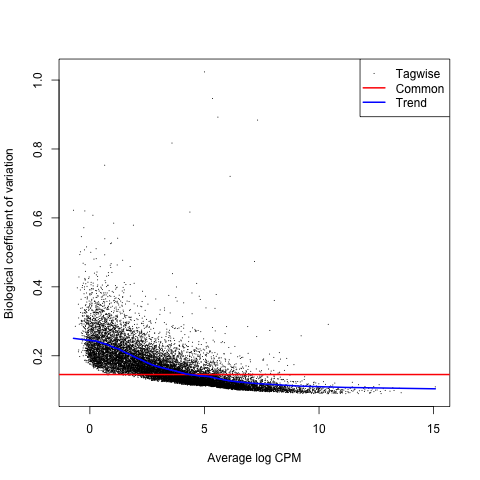

CPU times: user 5.19 s, sys: 209 ms, total: 5.4 s
Wall time: 6.03 s


In [8]:
%%time
%%R -i adata_agg -o tt_SE_vs_1h -o tt_SE_vs_6h -o tt_1h_vs_6h

# Call the function
outs <- fit_model(adata_agg)

fit <- outs$fit
y <- outs$y

plotMDS(y, col=ifelse(y$samples$group == "stim", "red", "blue"))
plotBCV(y)

print(colnames(y$design))

### SE v 1h
myContrast <- makeContrasts('group1h-groupSE', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)

# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt_SE_vs_1h <- topTags(qlf, n = Inf)
tt_SE_vs_1h <- tt_SE_vs_1h$table

### SE vs 6h
myContrast <- makeContrasts('group6h-groupSE', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)

# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt_SE_vs_6h <- topTags(qlf, n = Inf)
tt_SE_vs_6h <- tt_SE_vs_6h$table

### 1h vs 6h
myContrast <- makeContrasts('group6h-group1h', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)

# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt_1h_vs_6h <- topTags(qlf, n = Inf)
tt_1h_vs_6h <- tt_1h_vs_6h$table

In [9]:
tt_SE_vs_1h['gene'] = tt_SE_vs_1h.index
tt_SE_vs_6h['gene'] = tt_SE_vs_6h.index
tt_1h_vs_6h['gene'] = tt_1h_vs_6h.index

In [10]:
# list all tt with FDR < 0.05
tt_SE_vs_1h[tt_SE_vs_1h['FDR'] < 0.05]

,logFC,logCPM,F,PValue,FDR,gene
Mir670hg,1.362609,4.632315,76.167647,6.972020e-07,0.005896,Mir670hg
Sik2,1.028570,7.181167,74.878270,7.689708e-07,0.005896,Sik2
Tnfrsf25,1.542985,4.114458,62.032063,2.228288e-06,0.007827,Tnfrsf25
Ntrk2,0.866295,9.945665,60.947252,2.458047e-06,0.007827,Ntrk2
Kdm7a,1.001227,6.836766,60.537788,2.551769e-06,0.007827,Kdm7a
Osbpl6,0.647359,9.283349,53.558967,4.998716e-06,0.012777,Osbpl6
Sik3,0.660254,8.630848,47.528534,9.492222e-06,0.019792,Sik3
Gm29865,-1.315066,3.776909,46.780380,1.032453e-05,0.019792,Gm29865
Map2,0.586760,9.414053,41.931411,1.829533e-05,0.031175,Map2
Gfra1,1.114583,5.431543,38.442672,2.853266e-05,0.039831,Gfra1


In [11]:
# list all tt with FDR < 0.05
tt_SE_vs_6h[tt_SE_vs_6h['FDR'] < 0.05]

,logFC,logCPM,F,PValue,FDR,gene


In [12]:
tt_1h_vs_6h[tt_1h_vs_6h['FDR'] < 0.05]

,logFC,logCPM,F,PValue,FDR,gene
